Goal: Build Q-learning as the main event, using a lightweight value-iteration solve of the same environment purely as a correctness check — not a separate project, just the ground-truth answer key for Q-learning to be validated against.

Phase 1: Known-environment baseline

Implement the textbook's 5×5 Gridworld (same spec as before: wormholes at A/B, off-grid penalty, γ=0.9).
Run value iteration to convergence, check against Table 14.1 as a quick correctness sanity check.
Extract and store the optimal policy — this becomes your answer key, not a deliverable in its own right.
Kept intentionally light — just enough Bellman-equation/value-iteration exposure to say you've implemented Ch14's core algorithm and to get a verified ground truth, without treating it as equal in scope to Q-learning.

Phase 2: Q-learning, model-free

Same Gridworld, but now the agent doesn't know rewards/transitions upfront — must learn Q(s,a) purely through experience.
Epsilon-greedy exploration/exploitation, with epsilon decay over training.
Q-learning update rule, run over many episodes, tracking reward-per-episode to visualize learning (matplotlib).
Extract the greedy policy from the learned Q-table.
Correctness check: compare this learned policy directly against Phase 1's value-iteration policy — they should mostly agree.

In [ ]:
##in this example, transition function states the result of an action (reward and new location) with certainty
from os import stat_result
import numpy as np
import math
from tabulate import tabulate
starting_grid = np.zeros((5, 5))
def transition(state, x):
  (a,b) = state
  if state == (0,1):
    next_state = (4,1)
    payoff = 10
  elif state == (0,3):
    next_state = (2,3)
    payoff = 5
  elif x == 'left' and 0<b<=4:
    next_state = (a, b-1)
    payoff = 0
  elif x == 'right' and 0<=b<4:
    next_state = (a, b+1)
    payoff = 0
  elif x == 'down' and 0<=a<4:
    next_state = (a+1, b)
    payoff = 0
  elif x == 'up' and 0<a<=4:
    next_state = (a-1, b)
    payoff = 0
  else:
    next_state = (a,b)
    payoff = -1
  return next_state, payoff
print(transition((0,1), 'up'))
print(transition((0,3), 'down'))
print(transition((0,2), 'left'))
print(transition((2,2), 'left'))
#because whatever action is chosen only has one possible outcome (next state and reward based on decision are 100% predictable) -> v(s) = max_a[r(s,a) + gamma*v(s')], with gamma*v(s') being the discounted value of whatever state is landed in
#if standing on a state, want to know what's the best value possible from here, so need to know reward for each of the 4 possible options, as well how good the state you land on is (how good the state is starts off with no info and gets updated as you go, with this data held in v_optimized matrix)
v = np.zeros((5, 5))
v_optimized = np.zeros((5,5))
gamma = 0.9
num_steps = 300
optimal_direction = {}
for i in range(num_steps):
  for row in range(5):
    for col in range(5):
      running_max = -math.inf
      s = (row, col)
      for a in ['up', 'down', 'left', 'right']:
        next_state, payoff = transition(s, a)
        (x,y) = next_state
        if (payoff + (gamma * v[x][y])) > running_max:
          running_max = payoff + (gamma * v[x][y])
          max_direction = (a)
          v_optimized[row][col] = running_max
          optimal_direction[(row, col)] = a
  v = v_optimized.copy()
print(v_optimized)
policy = []
for row in range(5):
  policy_subset = []
  for col in range(5):
    policy_subset.append(optimal_direction[(row, col)])
  policy.append(policy_subset)
print(tabulate(policy))

((4, 1), 10)
((2, 3), 5)
((0, 1), 0)
((2, 1), 0)
[[21.97748529 24.4194281  21.97748529 19.4194281  17.47748529]
 [19.77973676 21.97748529 19.77973676 17.80176308 16.02158677]
 [17.80176308 19.77973676 17.80176308 16.02158677 14.4194281 ]
 [16.02158677 17.80176308 16.02158677 14.4194281  12.97748529]
 [14.4194281  16.02158677 14.4194281  12.97748529 11.67973676]]
-----  --  ----  ----  ----
right  up  left  up    left
up     up  up    left  left
up     up  up    up    up
up     up  up    up    up
up     up  up    up    up
-----  --  ----  ----  ----


1.9375788958017068 18.45018449583042


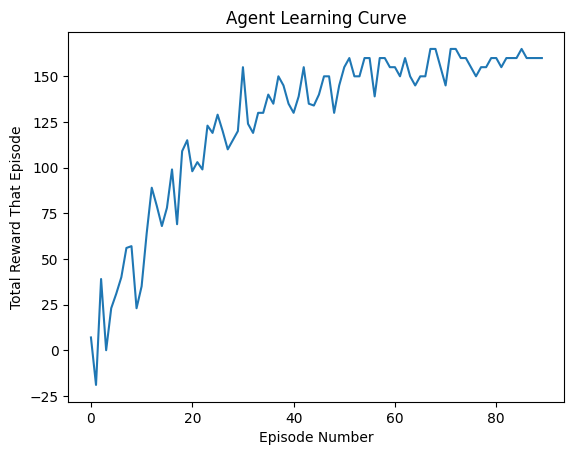

-----  -----  -----  ----  ----
right  down   left   left  left
right  up     right  up    left
right  up     right  up    up
up     right  up     up    left
right  up     up     up    up
-----  -----  -----  ----  ----


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
#Q-Learning
#build data structure of 100 numbers (25 states x 4 actions), the only way to update the estimate for a state is for the agent to be in a specific state and take a specific action (no longer deterministc outcome for each action, have to learn it)
actions = ['left', 'right', 'up', 'down']
Q_pair = {}
for row in range(5):
  for col in range(5):
    for a in actions:
      state = (row, col)
      Q_pair[(state, a)] = 0
#epsilon greedy - with probability epsilon, pick a completely random action, regardless of present Q-values, with probability 1-epsilon, pick the greedy (highest Q-value) option, gurantees that every action from every state gets sampled occasionally, allowing the agent to discover for itself the optimal choice
#epsilon typically starts high early in training and decays over time because early on, every Q-value is a near random guess, so exploring options is cheap, but as tests go on, real data starts to get accumulated, meaning the Q-values start reflecting the true structure of the environment, and exploring becomes expensive when the greedy action increasingly becomes the genuinely best option
#need to generate a random starting state at the start of the loop and follow it, can't go through every possible state like before
epsilon = 0.9999
gamma = 0.9
alpha = 0.1
history_of_episode_payoffs = []
def Q_pair_selection(current_state):
    if random.random() <= 1-epsilon:
      running_max = -math.inf
      for a in actions:
        if Q_pair[(current_state, a)] > running_max:
          running_max = Q_pair[(current_state, a)]
          choice = a
      next_state, payoff = transition(current_state, choice)
      return choice, next_state, payoff
    else:
      choice = random.choice(actions)
      next_state, payoff = transition(current_state, choice)
      return choice, next_state, payoff
def max_next_state(next_state):
  running_max = -math.inf
  for a in actions:
    if Q_pair[(next_state, a)] > running_max:
      running_max = Q_pair[(next_state, a)]
  return running_max
while epsilon >= 0.01:
  row = np.random.randint(0,5)
  col = np.random.randint(0,5)
  current_state = (row, col)
  exploration_steps = 100
  exploration_payoff = 0
  while exploration_steps != 0:
    this_choice, next_state, payoff = Q_pair_selection(current_state)
    next_choice_max = max_next_state(next_state)
    Q_pair[(current_state, this_choice)] = Q_pair[(current_state, this_choice)] + alpha * (payoff + gamma * next_choice_max - Q_pair[(current_state, this_choice)])
    current_state = next_state
    exploration_payoff += payoff
    exploration_steps -= 1
  history_of_episode_payoffs.append(exploration_payoff)
  epsilon = epsilon * 0.95
print(Q_pair[((0,1), 'up')], Q_pair[((0,3), 'left')])
plt.plot(history_of_episode_payoffs)
plt.xlabel("Episode Number")
plt.ylabel("Total Reward That Episode")
plt.title("Agent Learning Curve")
plt.show()
optimal_direction_Q = {}
policy = []
for row in range(5):
  for col in range(5):
    state = (row, col)
    running_max = -math.inf
    for a in actions:
      if Q_pair[(state, a)] > running_max:
        running_max = Q_pair[(state, a)]
        optimal_move = a
    optimal_direction_Q[state] = optimal_move
for row in range(5):
  policy_subset = []
  for col in range(5):
    policy_subset.append(optimal_direction_Q[(row, col)])
  policy.append(policy_subset)
print(tabulate(policy))